In [ ]:
import os
from pathlib import Path

# Localiza a raiz do projeto de forma robusta (funciona em VS Code, JupyterLab, etc.)
def _find_project_root():
    # VS Code expõe o caminho do notebook nesta variável
    nb_file = globals().get('__vsc_ipynb_file__') or locals().get('__vsc_ipynb_file__')
    if nb_file:
        return Path(nb_file).resolve().parent.parent
    # JupyterLab / linha de comandos
    try:
        import ipynbname
        return ipynbname.path().parent.parent
    except Exception:
        pass
    # Último recurso: working directory atual sobe um nível
    cwd = Path().resolve()
    if cwd.name == 'notebooks':
        return cwd.parent
    return cwd

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
print(f"✓ Working directory: {PROJECT_ROOT}")


# Matriz de Pesos Espaciais — Aveiro 

Este notebook implementa a **análise de econometria espacial** para os 17559 edifícios do município de Aveiro, organizado ao nível do código postal de 7 dígitos (CP7).

O pipeline cobre cinco fases principais:

| # | Fase | Objetivo |
|---|------|----------|
| 1 | Carregamento e alinhamento dos dados | Unir geometrias (GPKG) com indicadores técnico-económicos (CSV) |
| 2 | Construção da Matriz de Pesos Espaciais *W* | Definir a estrutura de vizinhança entre CP7s |
| 3 | Diagnóstico e tratamento de ilhas | Substituir contiguidade Queen por KNN quando existem CP7s isolados |
| 4 | Análise de Autocorrelação Espacial | Índice de Moran Global + LISA (clusters locais) |
| 5 | Modelos de Regressão Espacial | SAR (Spatial Lag) e SEM (Spatial Error) |
| 6 | Optimização MILP | Selecionar os CP7s a financiar com orçamento de 5 M€ |



## 0. Importações


In [2]:
import geopandas as gpd
import pandas as pd
import libpysal
import matplotlib.pyplot as plt

## 1. Carregamento e Alinhamento dos Dados

São lidos dois ficheiros:

- **`producao_pv_cp7.gpkg`** — GeoPackage com os **polígonos geográficos** de cada CP7, incluindo a coluna `area_util_m2` (área de telhado aproveitável, já calculada na pipeline de produção como `area_m2 × 0.40`).
- **`comparacao_final_limpa_cp7.csv`** — CSV com os **indicadores técnico-económicos** por CP7 (consumo anual, produção fotovoltaica, taxa de autossuficiência, etc.).

O `merge` é feito com `how="inner"`, garantindo que apenas os CP7s com dados válidos em ambos os ficheiros entram na análise.  
Resultado esperado: **558 CP7s** (de 936 com geometria, apenas 558 têm registos de consumo suficientes no CSV).


In [11]:
# ==========================================
# 1. CARREGAMENTO E ALINHAMENTO DOS DADOS
# ==========================================
print("A carregar dados geográficos e tabulares...")

# AJUSTA ESTES CAMINHOS
GPKG_PATH    = r"data/raw/producao_pv_cp7.gpkg"
CSV_PATH     = r"data/processed/comparacao_final_limpa_cp7.csv"
CONSUMO_PATH = r"data/raw/serie_consumo_cp7_2024_2025_v2.csv"

gdf_geo  = gpd.read_file(GPKG_PATH)
df_dados = pd.read_csv(CSV_PATH)

# Merge: mantém só os CP7 com dados válidos nos dois ficheiros
# O GPKG tem 1313 CP7 (todos os que têm geometria)
# O CSV tem 691 CP7 (filtrados por >= 70 registos de consumo)
# O inner join garante que W e os dados têm sempre o mesmo n
gdf = gdf_geo.merge(df_dados, on="cp7", how="inner")

print(f"Geometrias no GPKG          : {len(gdf_geo)} CP7s")
print(f"CP7s válidos no CSV         : {len(df_dados)} CP7s")
print(f"CP7s após merge (inner)     : {len(gdf)} CP7s")
print(f"Colunas disponíveis         : {list(gdf.columns)}")

A carregar dados geográficos e tabulares...
Geometrias no GPKG          : 936 CP7s
CP7s válidos no CSV         : 558 CP7s
CP7s após merge (inner)     : 558 CP7s
Colunas disponíveis         : ['cp7', 'building_postal_fragment_area_m2', 'area_util_m2', 'potencia_kwp', 'producao_kwh_ano', 'geometry', 'consumo_anual_kwh', 'n_registos', 'producao_total_kwh', 'balanco_kwh', 'taxa_autossuficiencia_%']


## 2–4. Construção da Matriz de Pesos *W*, Diagnóstico de Ilhas e Padronização

### 2. Contiguidade Queen (tentativa inicial)
A **Matriz de Pesos Espaciais (W)** define quais CP7s são "vizinhos" e com que peso — é o coração de toda a econometria espacial.  
A contiguidade **Queen** considera vizinhos todos os polígonos que partilhem pelo menos um ponto de fronteira (incluindo cantos), ao contrário da contiguidade **Rook**, que exige fronteira linear.

### 3. Diagnóstico e Tratamento de Ilhas
Detectaram-se **217 ilhas** (CP7s sem qualquer vizinho na malha Queen). Ilhas causam problemas numéricos nos modelos espaciais, pois o cálculo do I de Moran e dos modelos SAR/SEM pressupõe conectividade.

**Solução adoptada:** substituição da matriz Queen por **KNN com k = 4** (*k-Nearest Neighbors*).  
Cada CP7 passa a ter exactamente 4 vizinhos (os 4 CP7s cujos centroides são mais próximos), eliminando ilhas.  
Nota: ainda ficam 3 componentes desconexas — aceitável para este tamanho de amostra.

### 4. Padronização por Linha (`transform = 'r'`)
A padronização por linha garante que a soma dos pesos de cada vizinhança é 1, tornando os coeficientes das regressões comparáveis entre si e interpretáveis como médias ponderadas.


In [12]:
# ==========================================
# 2. CONSTRUÇÃO DA MATRIZ DE PESOS (QUEEN)
# ==========================================
print("A construir a Matriz de Pesos Espaciais (Queen)...")

w_queen = libpysal.weights.Queen.from_dataframe(gdf)

# ==========================================
# 3. DIAGNÓSTICO E TRATAMENTO DE ILHAS
# ==========================================
ilhas = w_queen.islands
print(f"Número de 'ilhas' detetadas: {len(ilhas)}")

if len(ilhas) > 0:
    print("Aviso: Existem ilhas. A substituir por KNN (k=4).")
    w = libpysal.weights.KNN.from_dataframe(gdf, k=4)
    print("Matriz substituída por KNN (k=4).")
else:
    w = w_queen

# ==========================================
# 4. PADRONIZAÇÃO POR LINHA
# ==========================================
w.transform = 'r'

print("\n=== RESUMO DA MATRIZ W ===")
print(f"Número total de observações (n) : {w.n}")
print(f"Média de vizinhos por CP7       : {w.mean_neighbors:.2f}")
print(f"Matriz padronizada por linha?   : {w.transform == 'R'}")

A construir a Matriz de Pesos Espaciais (Queen)...


C:\Users\carol\AppData\Local\Temp\ipykernel_30832\2769448435.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = libpysal.weights.Queen.from_dataframe(gdf)


Número de 'ilhas' detetadas: 217
Aviso: Existem ilhas. A substituir por KNN (k=4).
Matriz substituída por KNN (k=4).

=== RESUMO DA MATRIZ W ===
Número total de observações (n) : 558
Média de vizinhos por CP7       : 4.00
Matriz padronizada por linha?   : True


c:\Users\carol\AppData\Local\Programs\Python\Python314\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 264 disconnected components.
 There are 217 islands with ids: 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 37, 46, 54, 55, 58, 82, 95, 100, 101, 102, 103, 114, 136, 137, 144, 153, 155, 157, 158, 160, 161, 163, 166, 167, 168, 169, 171, 172, 174, 175, 176, 177, 178, 193, 198, 199, 205, 206, 209, 212, 215, 218, 219, 220, 221, 222, 226, 228, 233, 234, 236, 237, 238, 239, 240, 241, 242, 244, 245, 246, 248, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 263, 265, 266, 268, 272, 273, 274, 279, 280, 281, 282, 283, 284, 286, 288, 290, 291, 292, 294, 296, 297, 299, 300, 301, 302, 303, 304, 305, 306, 310, 315, 316, 317, 320, 323, 324, 328, 334, 339, 340, 342, 346, 350, 374, 376, 385, 388, 390, 394, 395, 396, 397, 398, 404, 410, 412, 413, 417, 423, 424, 426, 428, 433, 437, 440, 442, 443, 444, 445, 446, 449, 452, 456, 458, 460

## Índice de Moran Global

In [13]:
from esda.moran import Moran

y = gdf["taxa_autossuficiencia_%"].values

moran = Moran(y, w)
print(f"I de Moran : {moran.I:.4f}")
print(f"p-valor    : {moran.p_sim:.4f}")
print(f"z-score    : {moran.z_sim:.4f}")

I de Moran : 0.1703
p-valor    : 0.0010
z-score    : 6.2273


c:\Users\carol\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Índice de Moran Global — Interpretação

O **Índice de Moran (I)** mede a autocorrelação espacial global da variável `taxa_autossuficiencia_%`:

- **I ≈ 0** → distribuição aleatória no espaço (sem padrão)  
- **I > 0** → agrupamento espacial (valores altos junto de valores altos, e vice-versa)  
- **I < 0** → dispersão espacial (tabuleiro de xadrez)

Os resultados obtidos foram **I = 0.1703**, **p-valor = 0.001**, **z-score = 6.23**, o que indica:
- Autocorrelação espacial **positiva e estatisticamente significativa** (p < 0.001).
- Existe agrupamento geográfico da taxa de autossuficiência: zonas com alta produção solar tendem a estar próximas de outras zonas com alta produção, e vice-versa.

O p-valor é calculado por **simulação de Monte Carlo** (999 permutações por omissão no `esda`).

## LISA

In [14]:
from esda.moran import Moran_Local

lisa = Moran_Local(y, w)
gdf["lisa_q"]   = lisa.q
gdf["lisa_p"]   = lisa.p_sim
gdf["lisa_sig"] = lisa.p_sim < 0.05

labels = {1: "HH (cluster alto)", 2: "LH (outlier baixo)",
          3: "LL (cluster baixo)", 4: "HL (outlier alto)"}

sig = gdf[gdf["lisa_sig"]]
print(f"CP7s significativos (p<0.05): {len(sig)} de {len(gdf)}")
print()
for q, label in labels.items():
    n = (sig["lisa_q"] == q).sum()
    print(f"  {label}: {n} CP7s")

CP7s significativos (p<0.05): 105 de 558

  HH (cluster alto): 32 CP7s
  LH (outlier baixo): 18 CP7s
  LL (cluster baixo): 49 CP7s
  HL (outlier alto): 6 CP7s


### LISA — Indicadores Locais de Associação Espacial

O **Moran Local (LISA)** decompõe a autocorrelação global em contribuições individuais de cada CP7, identificando **clusters** e **outliers** espaciais estatisticamente significativos (p < 0.05).

| Quadrante | Significado |
|-----------|-------------|
| **HH** (Alto-Alto) | CP7 com alta autossuficiência rodeado de vizinhos com alta autossuficiência → **cluster de alto desempenho** |
| **LL** (Baixo-Baixo) | CP7 com baixa autossuficiência rodeado de vizinhos com baixa autossuficiência → **cluster de baixo desempenho** |
| **LH** (Baixo-Alto) | CP7 com baixa autossuficiência rodeado de vizinhos com alta → **outlier negativo** |
| **HL** (Alto-Baixo) | CP7 com alta autossuficiência rodeado de vizinhos com baixa → **outlier positivo** |

Resultados: **105 de 558 CP7s** são estatisticamente significativos (p < 0.05), distribuídos entre HH (32), LH (18), LL (49) e HL (6).

O mapa gerado é guardado em `mapa_lisa_autossuficiencia_88k.png`.

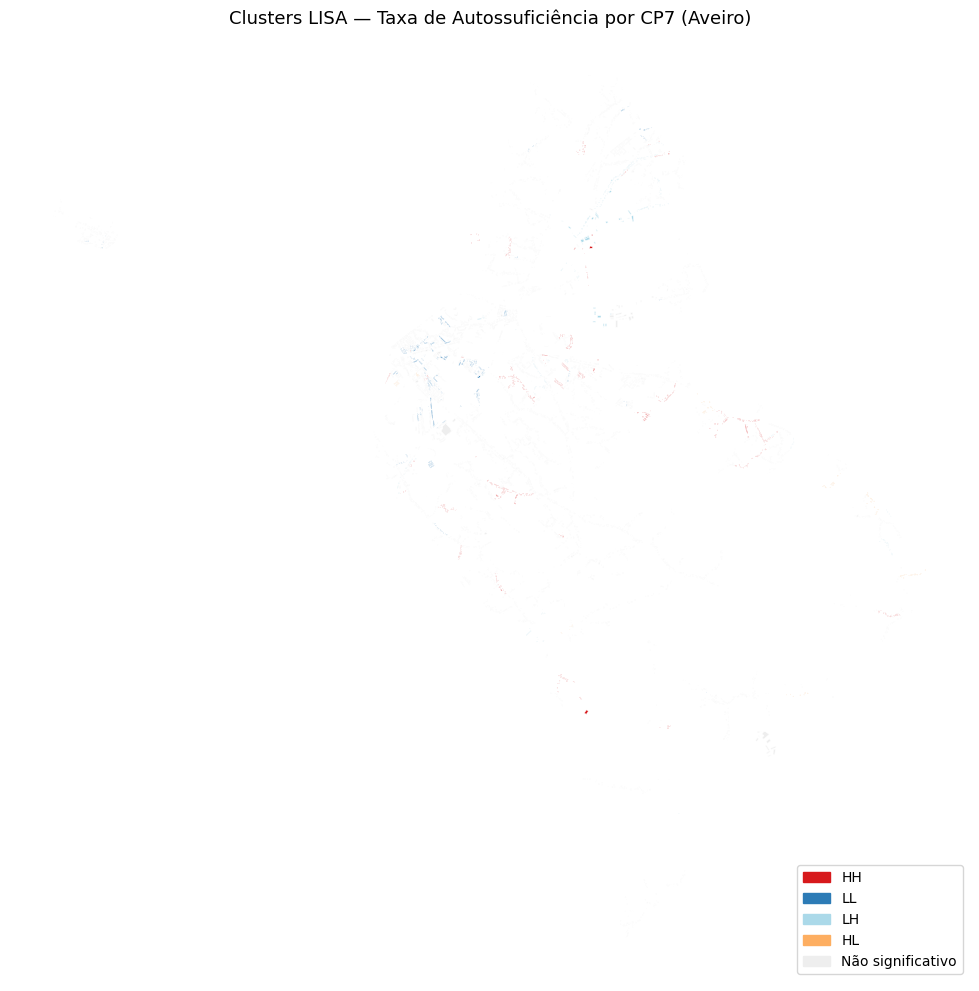

✓ Guardado: mapa_lisa_autossuficiencia_88k.png


In [15]:
import matplotlib.patches as mpatches

def lisa_categoria(row):
    if not row["lisa_sig"]:
        return "Não significativo"
    return {1: "HH", 2: "LH", 3: "LL", 4: "HL"}[row["lisa_q"]]

gdf["lisa_cat"] = gdf.apply(lisa_categoria, axis=1)

cores = {
    "HH": "#d7191c",
    "LL": "#2c7bb6",
    "LH": "#abd9e9",
    "HL": "#fdae61",
    "Não significativo": "#eeeeee"
}

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
for cat, cor in cores.items():
    gdf[gdf["lisa_cat"] == cat].plot(ax=ax, color=cor, edgecolor="white", linewidth=0.3)

patches = [mpatches.Patch(color=cor, label=cat) for cat, cor in cores.items()]
ax.legend(handles=patches, loc="lower right", fontsize=10)
ax.set_title("Clusters LISA — Taxa de Autossuficiência por CP7 (Aveiro)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("mapa_lisa_autossuficiencia_88k.png", dpi=150)
plt.show()
print("✓ Guardado: mapa_lisa_autossuficiencia_88k.png")

## Modelo SAR

**Nota:** `building_postal_fragment_area_m2` foi substituída por `area_util_m2`,
que representa a área útil do telhado já calculada na pipeline de produção
(= `area_m2 × 0.40`). O significado económico é equivalente: quanto maior
a área útil, maior o potencial de produção solar e portanto maior a taxa
de autossuficiência.

### Agregação para o Nível CP7

Os dados originais têm **uma linha por edifício** (88 k linhas). Para os modelos de regressão espacial, é necessário **uma linha por CP7**, pois a matriz *W* está definida nesse nível.

Operações de agregação:
- `area_util_m2` → **soma** (área total aproveitável de todos os edifícios do CP7)
- `potencia_total_kwp` → **soma** (potência fotovoltaica total instalável no CP7)
- `consumo_anual_kwh` → **first** (já está ao nível CP7 no CSV; todos os edifícios do mesmo CP7 partilham o mesmo valor)
- `n_registos` → **first** (idem)
- `taxa_autossuficiencia_%` → **first** (idem)
- `geometry` → **first** (polígono representativo do CP7)

Após remoção de NaN: **558 CP7s** válidos para modelação.

A análise de correlações revelou **colinearidade perfeita** entre `area_util_m2` e `potencia_total_kwp` (r = 1.00), pois `potencia_kwp = area_util_m2 × 0.225`.  
→ As células 12 e 13 estão comentadas (versões descartadas); o modelo definitivo usa apenas `area_util_m2`.


In [20]:
import numpy as np
from spreg import ML_Lag, ML_Error

# ── Agregar gdf para nível CP7 (uma linha por CP7) ──────────────────
gdf_cp7 = (
    gdf.groupby("cp7", dropna=False)
    .agg(
        area_util_m2        = ("area_util_m2", "sum"),
        potencia_total_kwp  = ("potencia_kwp", "sum"),  # já vem do CSV por CP7
        consumo_anual_kwh   = ("consumo_anual_kwh",      "first"),
        n_registos          = ("n_registos",             "first"),
        taxa_autossuficiencia = ("taxa_autossuficiencia_%", "first"),
        geometry            = ("geometry",               "first"),   # representativa
    )
    .reset_index()
)

# Converter de volta para GeoDataFrame
import geopandas as gpd
gdf_cp7 = gpd.GeoDataFrame(gdf_cp7, geometry="geometry", crs=gdf.crs)
gdf_cp7 = gdf_cp7.rename(columns={"taxa_autossuficiencia": "taxa_autossuficiencia_%"})

cols = ["taxa_autossuficiencia_%", "area_util_m2", "potencia_total_kwp",
        "consumo_anual_kwh", "n_registos"]

gdf_sdm = gdf_cp7[cols + ["geometry"]].dropna().copy()
print(f"Observações (CP7s) após remoção de NaN: {len(gdf_sdm)}")

print("\n=== CORRELAÇÕES ENTRE VARIÁVEIS EXPLICATIVAS ===")
print(gdf_sdm[cols[1:]].corr().round(2))

Observações (CP7s) após remoção de NaN: 558

=== CORRELAÇÕES ENTRE VARIÁVEIS EXPLICATIVAS ===
                    area_util_m2  potencia_total_kwp  consumo_anual_kwh  \
area_util_m2                1.00                1.00               0.29   
potencia_total_kwp          1.00                1.00               0.29   
consumo_anual_kwh           0.29                0.29               1.00   
n_registos                   NaN                 NaN                NaN   

                    n_registos  
area_util_m2               NaN  
potencia_total_kwp         NaN  
consumo_anual_kwh          NaN  
n_registos                 NaN  


### Modelo SAR Completo (versão de diagnóstico)

O **Spatial Lag Model (SAR)** — também chamado *Spatial AutoRegressive model* — inclui o lag espacial da variável dependente como regressor:

$$\text{taxa\_autossuf}_i = \rho \sum_j w_{ij} \cdot \text{taxa\_autossuf}_j + \beta_0 + \beta_1 \cdot \text{area\_util\_m2}_i + \dots + \varepsilon_i$$

Onde $\rho$ captura o efeito de *spillover* espacial: a taxa de autossuficiência de um CP7 é influenciada pela taxa dos seus vizinhos.

Esta primeira versão inclui todas as variáveis (`area_util_m2`, `potencia_total_kwp`, `consumo_anual_kwh`, `n_registos`) para diagnóstico. O aviso `Variable(s) ['n_registos'] removed for being constant` indica que `n_registos` é constante após remoção de NaN, sendo automaticamente descartada.

**Problema detectado:** `area_util_m2` e `potencia_total_kwp` são perfeitamente colineares (r = 1.0), fazendo com que ambas tenham z-statistic ≈ 0. → Solução na célula seguinte.


In [23]:
# Recriar W apenas para as observações válidas
w_sdm = libpysal.weights.KNN.from_dataframe(gdf_sdm, k=4)
w_sdm.transform = "r"

y_sdm = gdf_sdm["taxa_autossuficiencia_%"].values.reshape(-1, 1)

# Modelo SAR completo
print("=== MODELO SPATIAL LAG (SAR) — COMPLETO ===")
sar = ML_Lag(
    y_sdm,
    gdf_sdm[["area_util_m2", "potencia_total_kwp", "consumo_anual_kwh", "n_registos"]].values,
    w_sdm,
    name_y="taxa_autossuficiencia_%",
    name_x=["area_util_m2", "potencia_total_kwp", "consumo_anual_kwh", "n_registos"],
    name_w="KNN_k4"
)
print(sar.summary)

c:\Users\carol\AppData\Local\Programs\Python\Python314\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


=== MODELO SPATIAL LAG (SAR) — COMPLETO ===
ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      KNN_k4
Dependent Variable  :taxa_autossuficiencia_%                Number of Observations:         558
Mean dependent var  :    107.8894                Number of Variables   :           5
S.D. dependent var  :     89.6920                Degrees of Freedom    :         553
Pseudo R-squared    :      0.1928
Spatial Pseudo R-squared:  0.1768
Log likelihood      :  -3244.1263
Sigma-square ML     :   6501.8568                Akaike info criterion :    6498.253
S.E of regression   :     80.6341                Schwarz criterion     :    6519.874

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statisti

### Modelo SAR Corrigido + Spatial Error Model (SEM)

**SAR Corrigido:** Remove `potencia_total_kwp` (colinear com `area_util_m2`), ficando com:
- `area_util_m2` → **efeito positivo e significativo** (β ≈ 0.020, z ≈ 8.5): maior área de telhado aproveitável → maior taxa de autossuficiência. Faz sentido: mais área = mais painéis = mais produção.
- `consumo_anual_kwh` → **efeito negativo e significativo** (β ≈ -0.00001, z ≈ -7.0): maior consumo → menor taxa de autossuficiência. Também faz sentido: a mesma produção cobre uma fração menor de um consumo maior.
- `W_taxa_autossuficiencia_%` (ρ ≈ 0.223, z ≈ 4.2): **spillover espacial positivo e significativo** — confirma que a autossuficiência de um CP7 é influenciada pela dos seus vizinhos.
- **Pseudo R² ≈ 0.19**: o modelo explica ~19% da variância, aceitável dado o número reduzido de variáveis.

**SEM (Spatial Error Model):** Modela a autocorrelação espacial no **termo de erro** (em vez de no lag da variável dependente).  
- λ ≈ 0.189, p = 0.001 → autocorrelação nos resíduos, estatisticamente significativa.
- AIC SAR (6494.9) < AIC SEM (6502.0) → **o SAR é preferível ao SEM** para estes dados.

Os resultados do SAR corrigido são guardados em `resultados_sar_cp7_88k.gpkg`.


In [24]:
# SAR corrigido (sem colinearidade: remove potencia_total_kwp se colinear com area_util_m2)
X_clean = gdf_sdm[["area_util_m2", "consumo_anual_kwh", "n_registos"]].values

print("=== SAR CORRIGIDO ===")
sar2 = ML_Lag(
    y_sdm, X_clean, w_sdm,
    name_y="taxa_autossuficiencia_%",
    name_x=["area_util_m2", "consumo_anual_kwh", "n_registos"],
    name_w="KNN_k4"
)
print(sar2.summary)

print("\n=== SPATIAL ERROR MODEL (SEM) ===")
sem = ML_Error(
    y_sdm, X_clean, w_sdm,
    name_y="taxa_autossuficiencia_%",
    name_x=["area_util_m2", "consumo_anual_kwh", "n_registos"],
    name_w="KNN_k4"
)
print(sem.summary)

=== SAR CORRIGIDO ===
ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      KNN_k4
Dependent Variable  :taxa_autossuficiencia_%                Number of Observations:         558
Mean dependent var  :    107.8894                Number of Variables   :           4
S.D. dependent var  :     89.6920                Degrees of Freedom    :         554
Pseudo R-squared    :      0.1928
Spatial Pseudo R-squared:  0.1772
Log likelihood      :  -3243.4604
Sigma-square ML     :   6485.5356                Akaike info criterion :    6494.921
S.E of regression   :     80.5328                Schwarz criterion     :    6512.218

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----

c:\Users\carol\AppData\Local\Programs\Python\Python314\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      KNN_k4
Dependent Variable  :taxa_autossuficiencia_%                Number of Observations:         558
Mean dependent var  :    107.8894                Number of Variables   :           3
S.D. dependent var  :     89.6920                Degrees of Freedom    :         555
Pseudo R-squared    :      0.1542
Log likelihood      :  -3247.9886
Sigma-square ML     :   6611.3421                Akaike info criterion :    6501.977
S.E of regression   :     81.3102                Schwarz criterion     :    6514.950

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------

In [25]:
gdf_sdm["sar_residuals"] = sar2.u.flatten()
gdf_sdm["sar_fitted"]    = sar2.predy.flatten()
gdf_sdm.to_file("resultados_sar_cp7_88k.gpkg", driver="GPKG")
print("✓ Guardado: resultados_sar_cp7_88k.gpkg")

✓ Guardado: resultados_sar_cp7_88k.gpkg


## MILP

### MILP — Optimização com Programação Linear Inteira Mista

O **MILP (Mixed Integer Linear Programming)** resolve o problema de selecção de CP7s a financiar, dada uma restrição orçamental.

**Parâmetros económicos assumidos:**
- Orçamento disponível: **5 000 000 €**
- Custo de instalação: **900 €/kWp**
- Conversão área → potência: **0.225 kWp/m²** (a partir de painéis de 450 Wp e 2 m²)
- Performance Ratio: **PR = 0.80**
- Produção anual estimada: **1600 kWh/kWp × 0.80 = 1280 kWh/kWp/ano** (compatível com os valores PVGIS para Aveiro)

**Pré-processamento:**
- `kwp_max` = `area_util_m2 × 0.225` — potência máxima instalável fisicamente
- `deficit_kwh` = `max(consumo - producao, 0)` — energia em falta para autossuficiência
- `kwp_necessario` = `deficit_kwh / 1280` — potência necessária para eliminar o défice
- `kwp_instalavel` = `min(kwp_necessario, kwp_max)` — potência efectivamente instalável (limitada pela área)
- `custo_necessario` = `kwp_instalavel × 900` — investimento necessário por CP7

Resultado: 247 CP7s já autossuficientes, 311 com défice, custo total para eliminar todos os défices ≈ 45.8 M€ >> orçamento disponível de 5 M€.


In [26]:
import pulp

ORCAMENTO      = 5_000_000
CUSTO_KWP      = 900
KWP_POR_M2     = 0.225
PR             = 0.80
PRODUCAO_POR_KWP = 1600 * PR

# area_util_m2 vem do merge com o GPKG (coluna já existente)
df = gdf[["cp7", "area_util_m2", "consumo_anual_kwh",
          "producao_total_kwh", "taxa_autossuficiencia_%"]].copy()
df = df.dropna().reset_index(drop=True)

df["kwp_max"]        = df["area_util_m2"] * KWP_POR_M2
df["deficit_kwh"]    = np.maximum(df["consumo_anual_kwh"] - df["producao_total_kwh"], 0)
df["kwp_necessario"] = df["deficit_kwh"] / PRODUCAO_POR_KWP
df["kwp_instalavel"] = np.minimum(df["kwp_necessario"], df["kwp_max"])
df["custo_necessario"] = df["kwp_instalavel"] * CUSTO_KWP
df["ja_autossuficiente"] = df["taxa_autossuficiencia_%"] >= 100

print(f"CP7s já autossuficientes      : {df['ja_autossuficiente'].sum()}")
print(f"CP7s com déficit              : {(~df['ja_autossuficiente']).sum()}")
print(f"Custo total para todos        : {df['custo_necessario'].sum()/1e6:.1f} M€")
print(f"Orçamento disponível          : {ORCAMENTO/1e6:.1f} M€")

CP7s já autossuficientes      : 247
CP7s com déficit              : 311
Custo total para todos        : 45.8 M€
Orçamento disponível          : 5.0 M€


### Formulação e Resolução do Problema MILP

**Variáveis de decisão:** $x_i \in \{0, 1\}$ para cada CP7 $i$ com défice (se 1 → investir; se 0 → não investir)

**Função objectivo (maximizar):**
$$\max \sum_{i \in \text{défice}} x_i$$
→ Maximizar o número de CP7s que passam a ser autossuficientes.

**Restrição orçamental:**
$$\sum_{i} x_i \cdot \text{custo}_i \leq 5\,000\,000 €$$

**Restrições lógicas:**
- CP7s já autossuficientes têm $x_i = 0$ (não precisam de investimento)
- CP7s onde `kwp_instalavel < kwp_necessario` têm $x_i = 0$ (área insuficiente para eliminar o défice — investimento parcial não conta)

**Resultado:**
- Status: **Optimal** (solução óptima encontrada pelo solver CBC da PuLP)
- **112 CP7s** selecionados para investimento
- Custo utilizado: **4.89 M€** (restam 0.11 M€ não utilizáveis — os CP7s restantes custariam mais do que o disponível)
- Total autossuficientes após MILP: **359 de 558** (64.3% de cobertura municipal)

Os resultados são guardados em `milp_resultados_cp7_88k.csv`.


In [27]:
prob = pulp.LpProblem("CER_Aveiro_Autossuficiencia_88k", pulp.LpMaximize)
n    = len(df)
x    = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n)]

prob += pulp.lpSum([x[i] for i in range(n) if not df.loc[i, "ja_autossuficiente"]])
prob += pulp.lpSum([x[i] * df.loc[i, "custo_necessario"] for i in range(n)]) <= ORCAMENTO

for i in range(n):
    if df.loc[i, "ja_autossuficiente"]:
        prob += x[i] == 0
    if df.loc[i, "kwp_instalavel"] < df.loc[i, "kwp_necessario"]:
        prob += x[i] == 0

prob.solve(pulp.PULP_CBC_CMD(msg=0))

df["milp_investir"]       = [int(pulp.value(x[i])) for i in range(n)]
df["milp_autossuficiente"] = df["ja_autossuficiente"] | (df["milp_investir"] == 1)

investidos    = df[df["milp_investir"] == 1]
custo_total   = investidos["custo_necessario"].sum()
cp7s_autossuf = df["milp_autossuficiente"].sum()

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"CP7s seleccionados para investimento : {len(investidos)}")
print(f"Custo total utilizado                : {custo_total/1e6:.2f} M€")
print(f"Orçamento restante                   : {(ORCAMENTO - custo_total)/1e6:.2f} M€")
print(f"CP7s autossuficientes após MILP      : {cp7s_autossuf} de {n}")
print(f"Taxa de cobertura municipal          : {cp7s_autossuf/n*100:.1f}%")

df.to_csv("milp_resultados_cp7_88k.csv", index=False)
print("\n✓ Guardado: milp_resultados_cp7_88k.csv")

Status: Optimal
CP7s seleccionados para investimento : 112
Custo total utilizado                : 4.89 M€
Orçamento restante                   : 0.11 M€
CP7s autossuficientes após MILP      : 359 de 558
Taxa de cobertura municipal          : 64.3%

✓ Guardado: milp_resultados_cp7_88k.csv


### Visualização da Solução MILP

Mapa coroplético com três categorias:

| Cor | Categoria | Descrição |
|-----|-----------|-----------|
|  Azul | Já autossuficiente (baseline) | 247 CP7s que já produzem ≥ consumo sem investimento adicional |
|  Verde | Investimento MILP | 112 CP7s seleccionados pelo optimizador para receberem painéis |
|  Magenta | Défice persistente | 199 CP7s que ficam sem cobertura por insuficiência orçamental ou de área |

O mapa é exportado para `mapa_milp_aveiro_88k.png` (200 dpi, fundo escuro para contraste visual).  
As estatísticas chave são sobrepostas no canto inferior esquerdo: baseline, resultado pós-MILP, investimento e ganho em pontos percentuais.


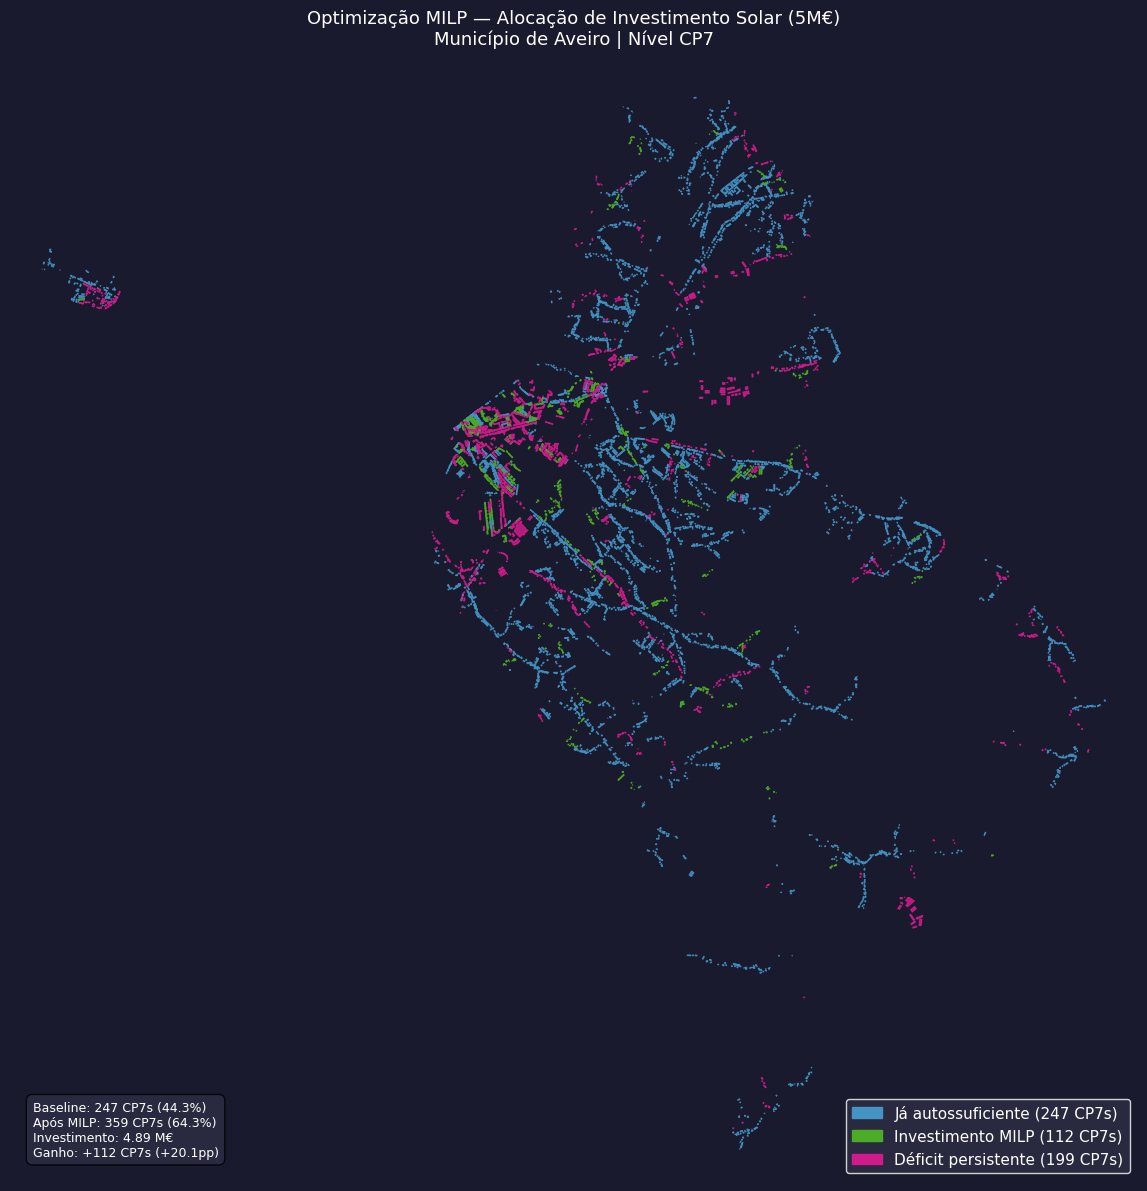

✓ Guardado: mapa_milp_aveiro_88k.png


In [28]:
gdf_milp = gdf.merge(
    df[["cp7", "milp_investir", "milp_autossuficiente",
        "custo_necessario", "kwp_instalavel", "deficit_kwh"]],
    on="cp7", how="left"
)

def milp_cat(row):
    if row["milp_investir"] == 1:
        return "Investimento MILP"
    elif row["milp_autossuficiente"] == True:
        return "Já autossuficiente"
    else:
        return "Déficit persistente"

gdf_milp["milp_cat"] = gdf_milp.apply(milp_cat, axis=1)

cores = {
    "Já autossuficiente"  : "#4393c3",
    "Investimento MILP"   : "#4dac26",
    "Déficit persistente" : "#d01c8b",
}

fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#1a1a2e")
ax.set_facecolor("#1a1a2e")

for cat, cor in cores.items():
    gdf_milp[gdf_milp["milp_cat"] == cat].plot(
        ax=ax, color=cor, edgecolor=cor, linewidth=0.8, alpha=0.85)

bounds = gdf_milp.total_bounds
margin = (bounds[2] - bounds[0]) * 0.03
ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
ax.set_ylim(bounds[1] - margin, bounds[3] + margin)

patches = [
    mpatches.Patch(color=cor,
                   label=f"{cat} ({(gdf_milp['milp_cat']==cat).sum()} CP7s)")
    for cat, cor in cores.items()
]
ax.legend(handles=patches, loc="lower right", fontsize=11,
          facecolor="#2d2d44", edgecolor="white", labelcolor="white")
ax.set_title("Optimização MILP — Alocação de Investimento Solar (5M€)\nMunicípio de Aveiro | Nível CP7",
             fontsize=13, color="white", pad=15)
ax.axis("off")

autossuf_antes = int(df["ja_autossuficiente"].sum())
autossuf_depois = int(cp7s_autossuf)
ganho = autossuf_depois - autossuf_antes
textstr = (f"Baseline: {autossuf_antes} CP7s ({autossuf_antes/n*100:.1f}%)\n"
           f"Após MILP: {autossuf_depois} CP7s ({autossuf_depois/n*100:.1f}%)\n"
           f"Investimento: {custo_total/1e6:.2f} M€\n"
           f"Ganho: +{ganho} CP7s (+{ganho/n*100:.1f}pp)")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes,
        fontsize=9, color="white", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#2d2d44", alpha=0.8))

plt.tight_layout()
plt.savefig("mapa_milp_aveiro_88k.png", dpi=200, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print("✓ Guardado: mapa_milp_aveiro_88k.png")